## PTDF OPF notebook - import gen excel and load excel, and network data.


In [9]:
import pandas as pd

In [10]:
Lines = pd.read_csv('../data/Inputs_prepared/Lines.csv')
Links = pd.read_csv('../data/Inputs_prepared/Links.csv')
Transformers = pd.read_csv('../data/Inputs_prepared/Transformers.csv')

Transformers[Transformers['s_nom'].isna()]

,TransformerID,bus0,bus1,voltage_bus0,voltage_bus1,s_nom
79,80,relation/10695345-400,relation/10695345,400.0,400.0,NaN
80,81,way/1078532568-400,way/1078532568,400.0,525.0,NaN
81,82,way/109189896,way/143783006-400,450.0,400.0,NaN
82,83,way/1262971878,way/1262971878-275,320.0,275.0,NaN
83,84,way/137050527-275,way/137050527,275.0,500.0,NaN
84,85,way/148382435,way/148382435-275,500.0,275.0,NaN
85,86,way/23281217-400,way/23281217,400.0,270.0,NaN
86,87,way/297840585,way/297840585-400,600.0,400.0,NaN
87,88,way/375626500-400,way/375626500,400.0,600.0,NaN
88,89,way/536905500-400,way/536905500,400.0,400.0,NaN


In [11]:
Lines = Lines.rename(columns={
    'LineID': 'AssetID'
})

Links = Links.rename(columns={
    'LinkID': 'AssetID'
})

Transformers = Transformers.rename(columns={
    'TransformerID': 'AssetID'
})

Lines["type"] = "Line"
Links["type"] = "Link"
Transformers["type"] = "Transformer"

network = pd.concat([Lines, Links, Transformers], ignore_index=True)

network['AssetID'] = range(1, len(network)+1)

network

,AssetID,bus0,bus1,voltage,capacity,r,x,b,length,under_construction,type,link_name,voltage_bus0,voltage_bus1,s_nom
0,1,way/1307462736-275,way/86071326-275,275.0,921.668,2.200334,14.577213,0.000228,55008.35,f,Line,NaN,NaN,NaN,NaN
1,2,relation/7881280-400,relation/13110369-400,400.0,3574.953,0.420393,3.447219,0.000243,28026.17,f,Line,NaN,NaN,NaN,NaN
2,3,way/101077623-275,GB41-275,275.0,1843.335,0.046871,0.310518,0.000019,2343.53,f,Line,NaN,NaN,NaN,NaN
3,4,way/95279334-400,way/103915328-400,400.0,3574.953,0.425859,3.492045,0.000246,28390.61,f,Line,NaN,NaN,NaN,NaN
4,5,way/111528318-220,GB8-220,220.0,1474.668,1.584632,7.949573,0.000933,79231.62,f,Line,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,736,way/536905500-400,way/536905500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Transformer,NaN,400.0,400.0,NaN
736,737,way/568527671,way/166703766-275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Transformer,NaN,320.0,275.0,NaN
737,738,way/636630368-400,way/636630368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Transformer,NaN,400.0,320.0,NaN
738,739,way/642490160,way/310502642-275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Transformer,NaN,515.0,275.0,NaN


In [12]:
# import networkx as nx

# # Build an undirected graph
# G = nx.Graph()

# # Add all edges from your DataFrame
# for _, row in network.iterrows():
#     G.add_edge(row["bus0"], row["bus1"])

# # Number of connected components
# n_components = nx.number_connected_components(G)

# print("Number of connected components:", n_components)

# if n_components == 1:
#     print("✅ The network is fully connected.")
# else:
#     print("❌ The network is NOT fully connected.")
#     print("Connected components:")
#     for comp in nx.connected_components(G):
#         print(" - component with", len(comp), "buses")


In [18]:
network = network.rename(columns={
    'capacity': 'Capacity',
    'bus0': 'Bus0',
    'bus1': 'Bus1',
    'voltage': 'Voltage',
    'type': 'Type',
    })

network = network[['AssetID', 'Bus0', 'Bus1', 'Capacity', 'x', 'Voltage','Type']]

network['Capacity'] = network['Capacity'].fillna(Transformers['s_nom'].mean())
network['x'] = network['x'].fillna(0.01)
network['Voltage'] = network['Voltage'].fillna(400)
network

,AssetID,Bus0,Bus1,Capacity,x,Voltage,Type
0,1,way/1307462736-275,way/86071326-275,921.668000,14.577213,275.0,Line
1,2,relation/7881280-400,relation/13110369-400,3574.953000,3.447219,400.0,Line
2,3,way/101077623-275,GB41-275,1843.335000,0.310518,275.0,Line
3,4,way/95279334-400,way/103915328-400,3574.953000,3.492045,400.0,Line
4,5,way/111528318-220,GB8-220,1474.668000,7.949573,220.0,Line
...,...,...,...,...,...,...,...
735,736,way/536905500-400,way/536905500,2161.388097,0.010000,400.0,Transformer
736,737,way/568527671,way/166703766-275,2161.388097,0.010000,400.0,Transformer
737,738,way/636630368-400,way/636630368,2161.388097,0.010000,400.0,Transformer
738,739,way/642490160,way/310502642-275,2161.388097,0.010000,400.0,Transformer


## Save

In [19]:
units = pd.read_excel("Cost_and_Carbon.xlsx", sheet_name="Units_with_regions")
load_profile = pd.read_excel("Load.xlsx", sheet_name='2024-03-31')
load_weights = pd.read_excel("Load.xlsx", sheet_name='load_weights')

with pd.ExcelWriter("PTDF_OPF.xlsx") as writer:
    network.to_excel(writer, sheet_name="network", index=False)
    units.to_excel(writer, sheet_name="units", index=False)
    load_profile.to_excel(writer, sheet_name="load_profile", index=False)
    load_weights.to_excel(writer, sheet_name="load_weights", index=False)

1. network figure: line width -> capacity
2. interconnector capacity -> network

## Relate line width with capacity

In [23]:
import geopandas as gpd
from shapely.geometry import Point

Buses = pd.read_csv('../data/Inputs_prepared/Buses.csv')
buses_geometry = [Point(xy) for xy in zip(Buses['x'], Buses['y'])]

gdf_buses = gpd.GeoDataFrame(Buses, geometry=buses_geometry, crs="EPSG:4326")
buses_geo_map = gdf_buses.set_index('bus_name')['geometry'].to_dict()

network['node0_geom'] = network['Bus0'].map(buses_geo_map)
network['node1_geom'] = network['Bus1'].map(buses_geo_map)
network

,AssetID,Bus0,Bus1,Capacity,x,Voltage,Type,node0_geom,node1_geom
0,1,way/1307462736-275,way/86071326-275,921.668000,14.577213,275.0,Line,POINT (-4.724597383 56.32414272),POINT (-4.377262536 55.92984947)
1,2,relation/7881280-400,relation/13110369-400,3574.953000,3.447219,400.0,Line,POINT (-0.756037109 53.59806107),POINT (-0.80883446 53.35935915)
2,3,way/101077623-275,GB41-275,1843.335000,0.310518,275.0,Line,POINT (-1.48827082 53.40611605),POINT (-1.4685122 53.3912009)
3,4,way/95279334-400,way/103915328-400,3574.953000,3.492045,400.0,Line,POINT (-2.002022274 51.60760665),POINT (-2.150544287 51.39368201)
4,5,way/111528318-220,GB8-220,1474.668000,7.949573,220.0,Line,POINT (-2.977991295 56.52122917),POINT (-1.7589614 56.5849318)
...,...,...,...,...,...,...,...,...,...
735,736,way/536905500-400,way/536905500,2161.388097,0.010000,400.0,Transformer,POINT (-3.050363602 53.2365916),NaN
736,737,way/568527671,way/166703766-275,2161.388097,0.010000,400.0,Transformer,POINT (-2.950413996 57.52117497),POINT (-2.948227259 57.52262412)
737,738,way/636630368-400,way/636630368,2161.388097,0.010000,400.0,Transformer,POINT (-1.194313257 50.81814424),NaN
738,739,way/642490160,way/310502642-275,2161.388097,0.010000,400.0,Transformer,POINT (-1.540426916 55.14647596),POINT (-1.531549937 55.14120363)


In [30]:
from shapely.geometry import LineString
import matplotlib.pyplot as plt
network['node1_geom'] = network['node1_geom'].fillna(network['node0_geom'])
network

,AssetID,Bus0,Bus1,Capacity,x,Voltage,Type,node0_geom,node1_geom
0,1,way/1307462736-275,way/86071326-275,921.668000,14.577213,275.0,Line,POINT (-4.724597383 56.32414272),POINT (-4.377262536 55.92984947)
1,2,relation/7881280-400,relation/13110369-400,3574.953000,3.447219,400.0,Line,POINT (-0.756037109 53.59806107),POINT (-0.80883446 53.35935915)
2,3,way/101077623-275,GB41-275,1843.335000,0.310518,275.0,Line,POINT (-1.48827082 53.40611605),POINT (-1.4685122 53.3912009)
3,4,way/95279334-400,way/103915328-400,3574.953000,3.492045,400.0,Line,POINT (-2.002022274 51.60760665),POINT (-2.150544287 51.39368201)
4,5,way/111528318-220,GB8-220,1474.668000,7.949573,220.0,Line,POINT (-2.977991295 56.52122917),POINT (-1.7589614 56.5849318)
...,...,...,...,...,...,...,...,...,...
735,736,way/536905500-400,way/536905500,2161.388097,0.010000,400.0,Transformer,POINT (-3.050363602 53.2365916),POINT (-3.050363602 53.2365916)
736,737,way/568527671,way/166703766-275,2161.388097,0.010000,400.0,Transformer,POINT (-2.950413996 57.52117497),POINT (-2.948227259 57.52262412)
737,738,way/636630368-400,way/636630368,2161.388097,0.010000,400.0,Transformer,POINT (-1.194313257 50.81814424),POINT (-1.194313257 50.81814424)
738,739,way/642490160,way/310502642-275,2161.388097,0.010000,400.0,Transformer,POINT (-1.540426916 55.14647596),POINT (-1.531549937 55.14120363)


In [ ]:
assets = network.copy()

assets['geometry'] = assets.apply(
    lambda r: LineString([r['node0_geom'], r['node1_geom']]),
    axis=1
)

gdf_assets = gpd.GeoDataFrame(assets, geometry='geometry', crs="EPSG:4326")
gdf_assets

,AssetID,Bus0,Bus1,Capacity,x,Voltage,Type,node0_geom,node1_geom,geometry
0,1,way/1307462736-275,way/86071326-275,921.668000,14.577213,275.0,Line,POINT (-4.724597383 56.32414272),POINT (-4.377262536 55.92984947),"LINESTRING (-4.7246 56.32414, -4.37726 55.92985)"
1,2,relation/7881280-400,relation/13110369-400,3574.953000,3.447219,400.0,Line,POINT (-0.756037109 53.59806107),POINT (-0.80883446 53.35935915),"LINESTRING (-0.75604 53.59806, -0.80883 53.35936)"
2,3,way/101077623-275,GB41-275,1843.335000,0.310518,275.0,Line,POINT (-1.48827082 53.40611605),POINT (-1.4685122 53.3912009),"LINESTRING (-1.48827 53.40612, -1.46851 53.3912)"
3,4,way/95279334-400,way/103915328-400,3574.953000,3.492045,400.0,Line,POINT (-2.002022274 51.60760665),POINT (-2.150544287 51.39368201),"LINESTRING (-2.00202 51.60761, -2.15054 51.39368)"
4,5,way/111528318-220,GB8-220,1474.668000,7.949573,220.0,Line,POINT (-2.977991295 56.52122917),POINT (-1.7589614 56.5849318),"LINESTRING (-2.97799 56.52123, -1.75896 56.58493)"
...,...,...,...,...,...,...,...,...,...,...
735,736,way/536905500-400,way/536905500,2161.388097,0.010000,400.0,Transformer,POINT (-3.050363602 53.2365916),POINT (-3.050363602 53.2365916),"LINESTRING (-3.05036 53.23659, -3.05036 53.23659)"
736,737,way/568527671,way/166703766-275,2161.388097,0.010000,400.0,Transformer,POINT (-2.950413996 57.52117497),POINT (-2.948227259 57.52262412),"LINESTRING (-2.95041 57.52117, -2.94823 57.52262)"
737,738,way/636630368-400,way/636630368,2161.388097,0.010000,400.0,Transformer,POINT (-1.194313257 50.81814424),POINT (-1.194313257 50.81814424),"LINESTRING (-1.19431 50.81814, -1.19431 50.81814)"
738,739,way/642490160,way/310502642-275,2161.388097,0.010000,400.0,Transformer,POINT (-1.540426916 55.14647596),POINT (-1.531549937 55.14120363),"LINESTRING (-1.54043 55.14648, -1.53155 55.1412)"


In [32]:
caps = gdf_assets['Capacity'].astype(float)

cap_min = caps.min()
cap_max = caps.max()
cap_range = cap_max - cap_min if cap_max != cap_min else 1.0

cap_norm = (caps - cap_min) / cap_range          # 0–1
min_w, max_w = 0.3, 3.0                          # thickness range
gdf_assets['width'] = min_w + cap_norm * (max_w - min_w)

## Classify bus type

In [70]:
bus_with_units = units['Bus_name'].unique().tolist()
bus_with_loads = load_weights['Bus_name'].unique().tolist()

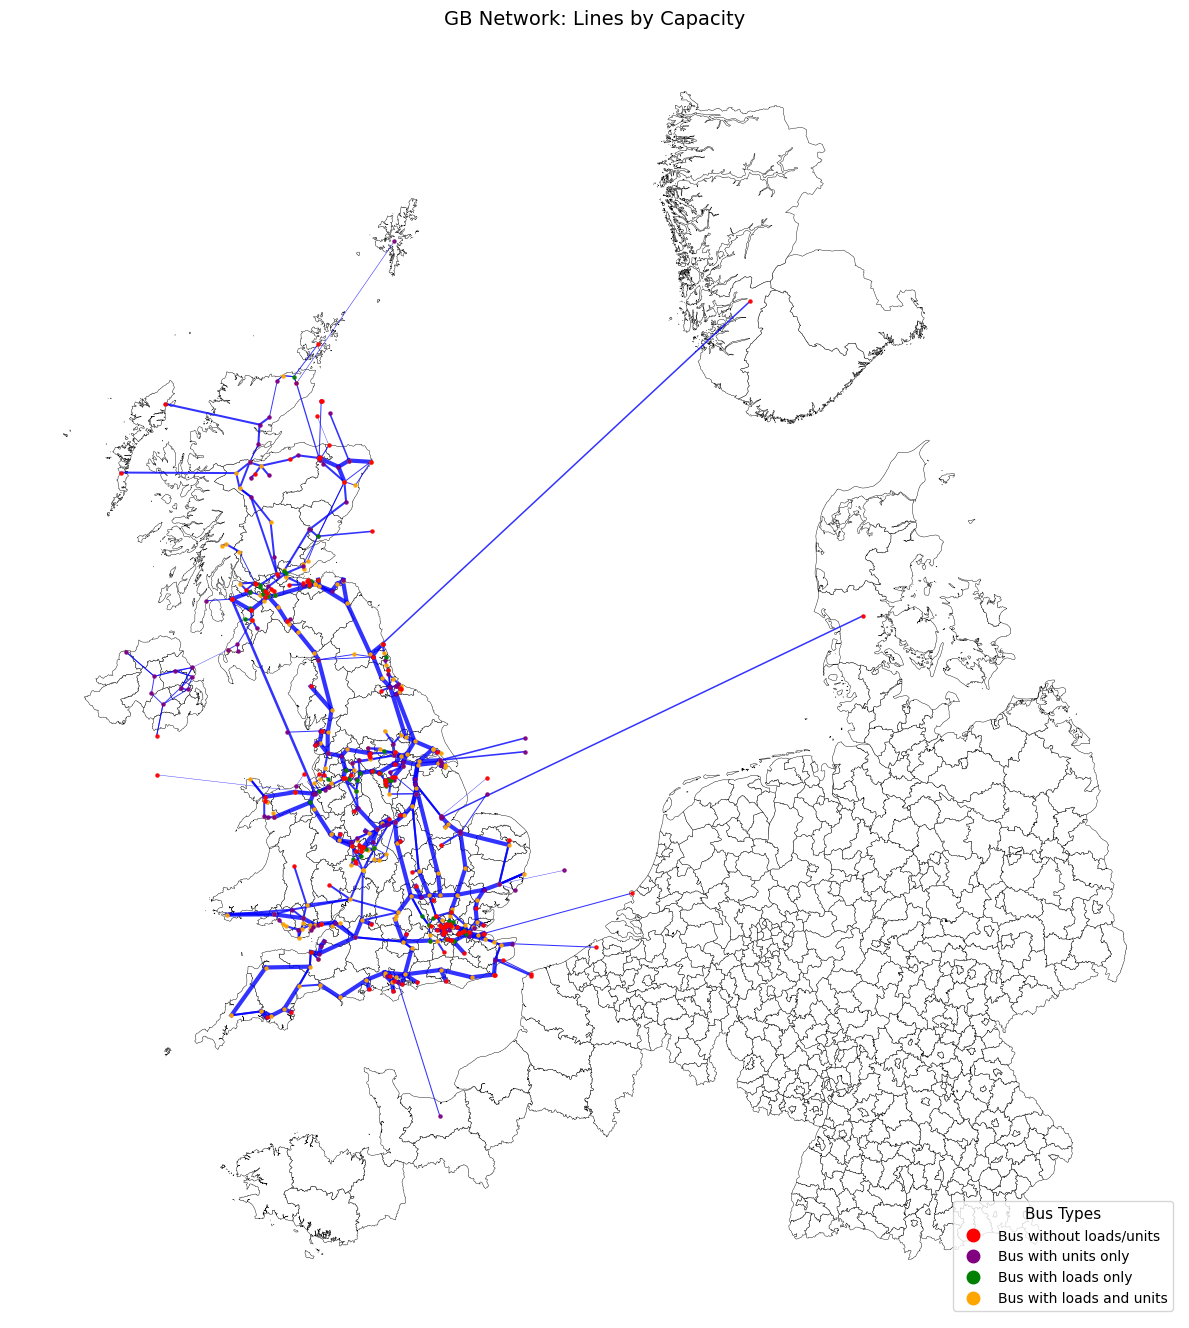

In [92]:
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(12, 18))

regions = gpd.read_file('./ref-nuts-2021-01m.geojson/NUTS_RG_01M_2021_4326_LEVL_3.geojson')

regions_uk = regions[regions['CNTR_CODE'] == 'UK']

regions_fr = regions[regions['NUTS_ID'].isin([
    'FRH01', 'FRH02', 'FRH03', 'FRH04',
    'FRD11', 'FRD12', 'FRD13', 'FRD21', 'FRD22',
    'FRE11', 'FRE12', 'FRE21', 'FRE22', 'FRE23'
])]

regions_be = regions[regions['CNTR_CODE'] == 'BE']
regions_nl = regions[regions['CNTR_CODE'] == 'NL']

regions_dk = regions[regions['NUTS_ID'].isin([
    'DK032',
    'DK041', 'DK042',
    'DK050',
    'DK031',
    'DK021', 'DK022'
])]

regions_no = regions[regions['NUTS_ID'].isin([
    'NO0A1', 'NO0A2',
    'NO091', 'NO092'
])]

regions_de = regions[regions['CNTR_CODE'] == 'DE']

regions_all = pd.concat(
    [regions_uk, regions_fr, regions_be, regions_nl, regions_dk, regions_no, regions_de],
    ignore_index=True
)



regions_all.plot(
    ax=ax,
    edgecolor='black',
    facecolor='white',
    linewidth=0.3
)

# plot lines, width depends on capacity
for _, row in gdf_assets.iterrows():
    x, y = row['geometry'].xy
    ax.plot(x, y, color='blue', linewidth=row['width'], alpha=0.8)

# plot bus points
mask_units = gdf_buses["bus_name"].isin(bus_with_units)
mask_loads = gdf_buses["bus_name"].isin(bus_with_loads)

mask_both       = mask_units & mask_loads
mask_units_only = mask_units & ~mask_loads
mask_loads_only = mask_loads & ~mask_units
mask_neither    = ~ (mask_units | mask_loads)

# both: orange
gdf_buses[mask_both].plot(
    ax=ax,
    color="orange",
    markersize=5,
    alpha=0.9,
    zorder=3
)

# units only: purple
gdf_buses[mask_units_only].plot(
    ax=ax,
    color="purple",
    markersize=5,
    alpha=0.9,
    zorder=3
)

# loads only: green
gdf_buses[mask_loads_only].plot(
    ax=ax,
    color="green",
    markersize=5,
    alpha=0.9,
    zorder=3
)

# neither: red
gdf_buses[mask_neither].plot(
    ax=ax,
    color="red",
    markersize=5,
    alpha=0.9,
    zorder=3
)
ax.set_title("GB Network: Lines by Capacity", fontsize=14)
ax.set_axis_off()

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='red',
           markeredgecolor='red', markersize=9, label='Bus without loads/units'),
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='purple',
           markeredgecolor='purple', markersize=9, label='Bus with units only'),
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='green',
           markeredgecolor='green', markersize=9, label='Bus with loads only'),
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='orange',
           markeredgecolor='orange', markersize=9, label='Bus with loads and units'),
]

ax.legend(
    handles=legend_handles,
    loc="lower right",      # 右下角，画在坐标轴里面
    fontsize=10,
    frameon=True,
    title="Bus Types",
    title_fontsize=11
)

plt.tight_layout()          # 不要再用 rect=[...] 了
plt.show()


/Users/zm348/opt/anaconda3/envs/NatureEV/lib/python3.13/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


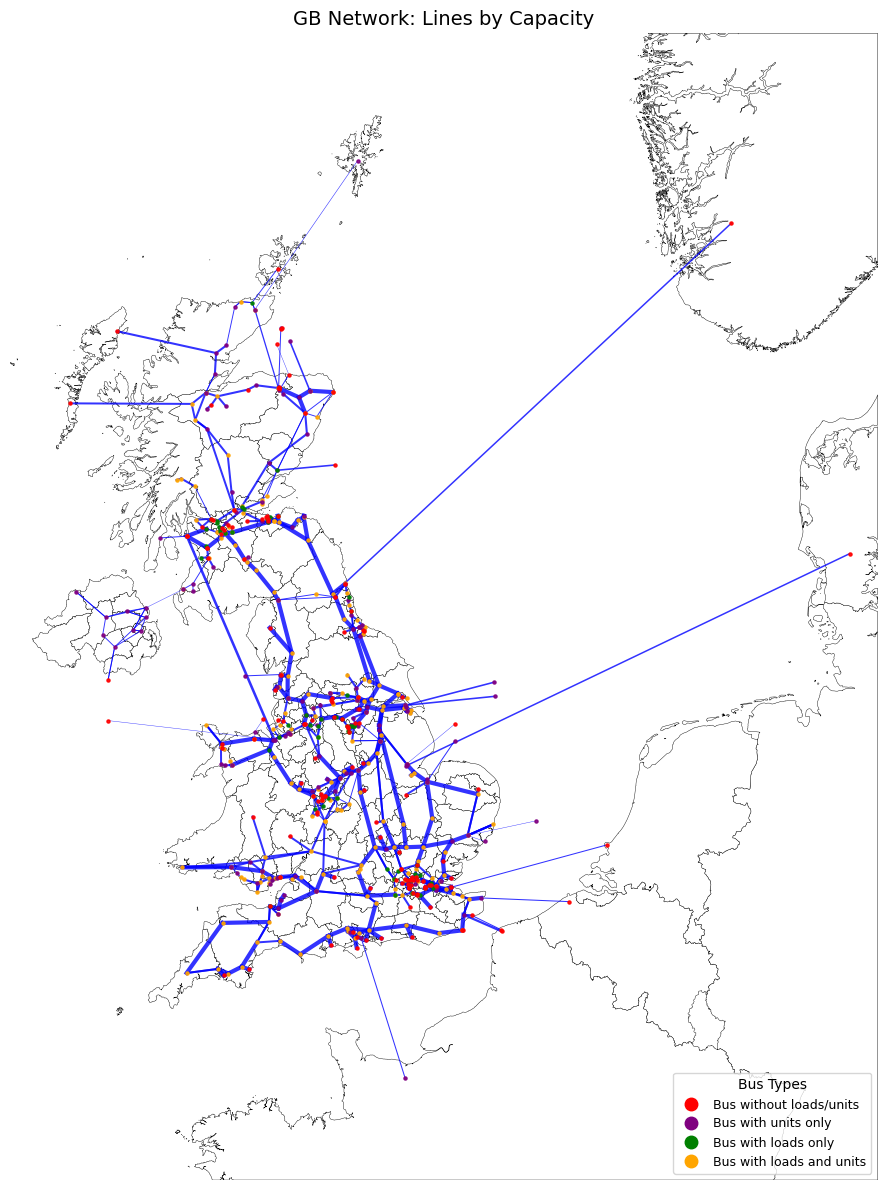

In [102]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box
from matplotlib.lines import Line2D

regions = gpd.read_file('./ref-nuts-2021-01m.geojson/NUTS_RG_01M_2021_4326_LEVL_3.geojson')

regions_uk = regions[regions['CNTR_CODE'] == 'UK']
neighbors = regions[regions['CNTR_CODE'].isin(['FR', 'BE', 'NL', 'DE', 'DK', 'NO'])]

minx, miny, maxx, maxy = regions_uk.total_bounds
expand_x = 4.0
expand_y_s = 2.0
expand_y_n = 1.0
shift_x = 4.0  # 往右移多少度，可自己调 1.0 / 1.5 / 2.0

bbox_poly = box(minx - expand_x + shift_x,
                miny - expand_y_s,
                maxx + expand_x + shift_x,
                maxy + expand_y_n)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs=regions.crs)


neighbors_clip = gpd.clip(neighbors, bbox_gdf)
neighbors_dissolved = neighbors_clip.dissolve(by='CNTR_CODE').reset_index()

regions_all = pd.concat(
    [regions_uk, neighbors_dissolved],
    ignore_index=True
)

fig, ax = plt.subplots(figsize=(10, 12))

regions_all.plot(
    ax=ax,
    edgecolor='black',
    facecolor='white',
    linewidth=0.3
)

for _, row in gdf_assets.iterrows():
    x, y = row['geometry'].xy
    ax.plot(x, y, color='blue', linewidth=row['width'], alpha=0.8, zorder=2)

mask_units = gdf_buses["bus_name"].isin(bus_with_units)
mask_loads = gdf_buses["bus_name"].isin(bus_with_loads)

mask_both       = mask_units & mask_loads
mask_units_only = mask_units & ~mask_loads
mask_loads_only = mask_loads & ~mask_units
mask_neither    = ~(mask_units | mask_loads)

gdf_buses[mask_both].plot(
    ax=ax,
    color="orange",
    markersize=5,
    alpha=0.9,
    zorder=3
)

gdf_buses[mask_units_only].plot(
    ax=ax,
    color="purple",
    markersize=5,
    alpha=0.9,
    zorder=3
)

gdf_buses[mask_loads_only].plot(
    ax=ax,
    color="green",
    markersize=5,
    alpha=0.9,
    zorder=3
)

gdf_buses[mask_neither].plot(
    ax=ax,
    color="red",
    markersize=5,
    alpha=0.9,
    zorder=3
)

ax.set_title("GB Network: Lines by Capacity", fontsize=14)
ax.set_axis_off()

ax.set_xlim(bbox_poly.bounds[0], bbox_poly.bounds[2])
ax.set_ylim(bbox_poly.bounds[1], bbox_poly.bounds[3])

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='red',
           markeredgecolor='red', markersize=9, label='Bus without loads/units'),
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='purple',
           markeredgecolor='purple', markersize=9, label='Bus with units only'),
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='green',
           markeredgecolor='green', markersize=9, label='Bus with loads only'),
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='orange',
           markeredgecolor='orange', markersize=9, label='Bus with loads and units'),
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    fontsize=9,
    frameon=True,
    title="Bus Types",
    title_fontsize=10
)

plt.tight_layout()
plt.show()


1. all points should have charging station, all regions should be equiped with at least one bus
2. legends for capacity